# Case study 4 — Transport-aware normalisation (COVID-19 PM2.5 at MY1)

Reproduces the paper's transport-aware normalisation case study (Sects.
*Transport-aware feature engineering* and *Transport-aware normalisation:
COVID-19 PM2.5*). Standard deweathering resamples only **local**
meteorology; PM2.5 at a London kerbside site is however strongly influenced
by **long-range transport**. Augmenting the predictors with HYSPLIT
back-trajectory features lets the normalisation marginalise over transport
too — the difference between the two deweathered series is the transport
contribution.

Bundled data: `load_my1_pm25()` (hourly PM2.5 + met, Jan–Aug 2020),
`load_traj_my1()` (6-hourly back-trajectory features), and a two-day sample
of raw HYSPLIT `tdump` files.

## 1. From raw HYSPLIT output to trajectory features

The bundled `tdump` sample shows the full pipeline: read endpoint files,
then reduce each trajectory to a feature vector (distance, path length,
speed, inflow bearing, heights, and residence-time fractions over source
regions).

In [1]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "4")

import matplotlib.pyplot as plt
import pandas as pd
import normet as nm
from normet.io.trajectory import read_trajectory_tdump

traj_dir = nm.datasets.example_traj_dir()
files = sorted(traj_dir.glob("tdump_*"))
one = read_trajectory_tdump(files[0])
print(f"{len(files)} tdump files; first has {len(one)} endpoints")
one.head()

8 tdump files; first has 73 endpoints


,traj,grid,year,month,day,hour,minute,fcast,age,lat,lon,height,pressure,datetime,age_h
0,1,1,20,1,1,0,0,0,0.0,51.525,-0.154,500.0,959.5,2020-01-01 00:00:00,0.0
1,1,1,19,12,31,23,0,1,-1.0,51.283,0.106,462.6,965.0,2019-12-31 23:00:00,-1.0
2,1,1,19,12,31,22,0,2,-2.0,51.054,0.375,439.5,970.5,2019-12-31 22:00:00,-2.0
3,1,1,19,12,31,21,0,3,-3.0,50.830,0.638,426.1,975.4,2019-12-31 21:00:00,-3.0
4,1,1,19,12,31,20,0,2,-4.0,50.622,0.871,409.9,980.0,2019-12-31 20:00:00,-4.0


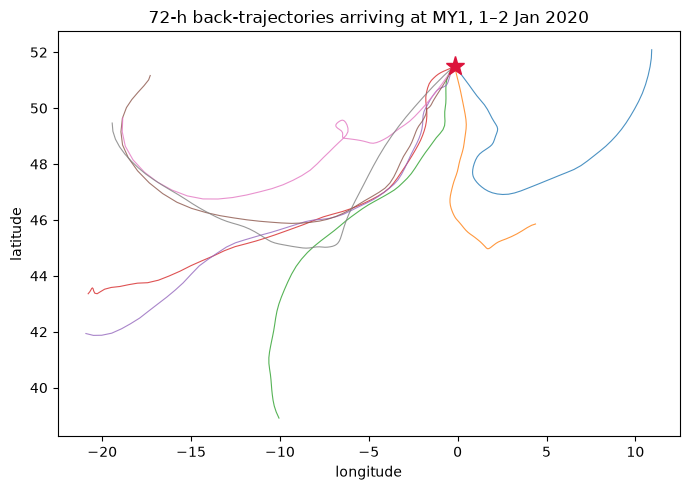

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))
for f in files:
    t = read_trajectory_tdump(f)
    ax.plot(t["lon"], t["lat"], lw=0.8, alpha=0.8)
ax.plot(-0.1546, 51.5225, marker="*", ms=14, color="crimson")  # MY1 receptor
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("72-h back-trajectories arriving at MY1, 1–2 Jan 2020")
plt.tight_layout()

## 2. Local-only vs transport-aware deweathering

Following the paper's design: both models share the same training rows,
split, seed, and search budget — the only difference is whether the
trajectory features are among the predictors (and are resampled).

In [3]:
panel = nm.datasets.load_my1_pm25().rename(columns={"pm25": "value"})
traj = nm.datasets.load_traj_my1()

MET_COLS = ["ws_era5", "wd_era5", "temp_era5", "blh", "sp", "ssrd", "tcc", "tp"]
TRAJ_COLS = [c for c in traj.columns if c.startswith("traj_")]
TIME_VARS = ["date_unix", "day_julian", "weekday", "hour"]
SEED = 7654321

# forward-fill the 6-hourly trajectory features to the hourly grid (nearest)
hour_grid = pd.DataFrame({"date": pd.date_range(traj["date"].min(), traj["date"].max(), freq="1h")})
traj_h = pd.merge_asof(hour_grid, traj.sort_values("date"), on="date", direction="nearest")

base = panel.loc[panel["value"].notna(), ["date", "value"] + MET_COLS]
base = base.merge(traj_h[["date"] + TRAJ_COLS], on="date", how="left")
for c in TRAJ_COLS:
    base[c] = base[c].fillna(traj_h[c].mean())
base = nm.add_date_variables(base)
print(f"analysis rows: {len(base)}")

analysis rows: 5715


In [4]:
cfg = {"n_trials": 4, "cv_folds": 2, "nrounds": 150, "early_stopping_rounds": 10}

# Model 1: local meteorology only
PREDS1 = MET_COLS + TIME_VARS
prep1, m1 = nm.build_model(base, value="value", backend="lightgbm", feature_names=PREDS1,
                           split_method="random", fraction=0.75, model_config=cfg,
                           seed=SEED, verbose=False, n_cores=4)
dw1 = nm.normalise(base, m1, feature_names=PREDS1, variables_resample=MET_COLS,
                   n_samples=100, seed=SEED, n_cores=4, verbose=False).reset_index()

# Model 2: transport-aware (met + trajectory features)
PREDS2 = MET_COLS + TRAJ_COLS + TIME_VARS
prep2, m2 = nm.build_model(base, value="value", backend="lightgbm", feature_names=PREDS2,
                           split_method="random", fraction=0.75, model_config=cfg,
                           seed=SEED, verbose=False, n_cores=4)
dw2 = nm.normalise(base, m2, feature_names=PREDS2, variables_resample=MET_COLS + TRAJ_COLS,
                   n_samples=100, seed=SEED, n_cores=4, verbose=False).reset_index()

print(nm.modStats(prep1, m1).loc[:, ["set", "R2", "RMSE"]] if hasattr(nm.modStats(prep1, m1), "loc") else "")

        set        R2      RMSE
0  training  0.889258  2.780254
1   testing  0.793910  3.871701
2       all  0.864342  3.089530


## 3. Transport contribution

The local-only model cannot resample what it never saw: any transport signal
stays in its "deweathered" series. The transport-aware model marginalises it
out. Their difference is the transport contribution to PM2.5.

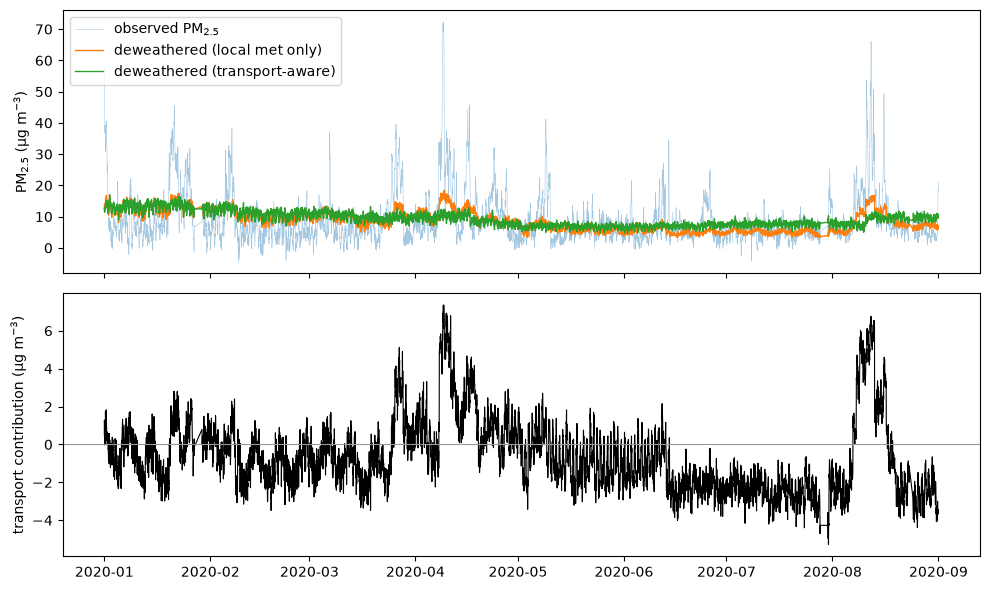

In [5]:
contrib = dw1[["date", "observed", "normalised"]].rename(columns={"normalised": "dw_local"}).merge(
    dw2[["date", "normalised"]].rename(columns={"normalised": "dw_transport"}), on="date")
contrib["transport_contribution"] = contrib["dw_local"] - contrib["dw_transport"]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(contrib["date"], contrib["observed"], lw=0.4, alpha=0.4, label="observed PM$_{2.5}$")
axes[0].plot(contrib["date"], contrib["dw_local"], lw=1, label="deweathered (local met only)")
axes[0].plot(contrib["date"], contrib["dw_transport"], lw=1, label="deweathered (transport-aware)")
axes[0].set_ylabel("PM$_{2.5}$ (µg m$^{-3}$)")
axes[0].legend()
axes[1].plot(contrib["date"], contrib["transport_contribution"], color="k", lw=0.8)
axes[1].axhline(0, color="0.6", lw=0.8)
axes[1].set_ylabel("transport contribution (µg m$^{-3}$)")
plt.tight_layout()

In [6]:
daily = contrib.set_index("date")["transport_contribution"].resample("D").mean()
print(f"mean transport contribution: {daily.mean():.2f} µg/m3")
print(f"days where transport dominates (>50% of deweathered local): "
      f"{(contrib['transport_contribution'] > 0.5 * contrib['dw_local']).mean() * 100:.0f}% of hours")

mean transport contribution: -0.63 µg/m3
days where transport dominates (>50% of deweathered local): 0% of hours
